# Benchmark: Set-distance metrics (e.g. hausdorff) for random point sets without optimization

In [1]:
import numpy as np
import pandas as pd
import plotnine as p9
from tqdm import tqdm, trange
import sys
import os
project_root = os.path.abspath('..')          # one level up from notebooks' directory
if project_root not in sys.path:
    sys.path.append(project_root)
from auction_module.bundling_and_bidding.fitness_functions.vrp_learn.distance import my_convex_hull_jaccard_distance, my_hausdorff_distance, my_MinWBMP, my_dice_similarity_coefficient, my_tsp_obj_val_diff, my_tsp_hull_jaccard_distance, my_modified_hausdorff_distance

In [16]:
rng = np.random.default_rng(1)

x_min, x_max, y_min, y_max = 0, 100, 0, 100
num_draws = 1000

records = []
for num_a in [8, 16]:
    for frac_b in [0.5, 1, 2]:
        num_b = int(num_a * frac_b)
        for draw in trange(num_draws, desc=f'{num_a} x {num_b}'):
            params = {
                'x_min': x_min,
                'x_max': x_max,
                'y_min': y_min,
                'y_max': y_max,
                'num_a': num_a,
                'num_b': num_b,
                'frac_b': frac_b 
            }
            set_a = rng.uniform((x_min, y_min), (x_max, y_max), size=(num_a, 2))
            set_b = rng.uniform((x_min, y_min), (x_max, y_max), size=(num_b, 2))
            df = pd.DataFrame(np.concat([set_a, set_b], axis=0), columns=['x', 'y'])
            # df['label'] = ["a"] * num_a + ["b"] * num_b
            # p9.qplot('x', 'y', df, geom='point', fill='label', size=4)
            metrics = {
                'hausdorff': my_hausdorff_distance(set_a, set_b),
                'modified hausdorff': my_modified_hausdorff_distance(set_a, set_b),
                'jaccard': my_convex_hull_jaccard_distance(set_a, set_b),
                # 'MinWBMP': my_MinWBMP(set_a, set_b),
                # 'dice': my_dice_similarity_coefficient(set_a, set_b),
                # 'TSP objective': my_tsp_obj_val_diff(set_a, set_b),
                # 'TSP hull': my_tsp_hull_jaccard_distance(set_a, set_b)
            }
            metrics['normalized hausdorff'] = metrics['hausdorff']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
            metrics['normalized modified hausdorff'] = metrics['modified hausdorff']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
            record = {**metrics, **params}
            records.append(record)
df = pd.DataFrame.from_records(records)
df

16 x 32: 100%|██████████| 1000/1000 [00:00<00:00, 5596.08it/s]


,hausdorff,modified hausdorff,jaccard,normalized hausdorff,normalized modified hausdorff,x_min,x_max,y_min,y_max,num_a,num_b,frac_b
0,34.253761,21.455268,0.494321,0.242211,0.151712,0,100,0,100,8,4,0.5
1,52.200926,22.329882,0.795275,0.369116,0.157896,0,100,0,100,8,4,0.5
2,49.091508,25.811843,0.476296,0.347129,0.182517,0,100,0,100,8,4,0.5
3,71.981463,29.277483,0.983331,0.508986,0.207023,0,100,0,100,8,4,0.5
4,36.764999,20.798937,0.761962,0.259968,0.147071,0,100,0,100,8,4,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,36.523305,13.196828,0.384418,0.258259,0.093316,0,100,0,100,16,32,2.0
5996,26.042762,12.243347,0.262277,0.184150,0.086574,0,100,0,100,16,32,2.0
5997,27.890999,10.558747,0.252211,0.197219,0.074662,0,100,0,100,16,32,2.0
5998,34.672825,14.487900,0.325508,0.245174,0.102445,0,100,0,100,16,32,2.0


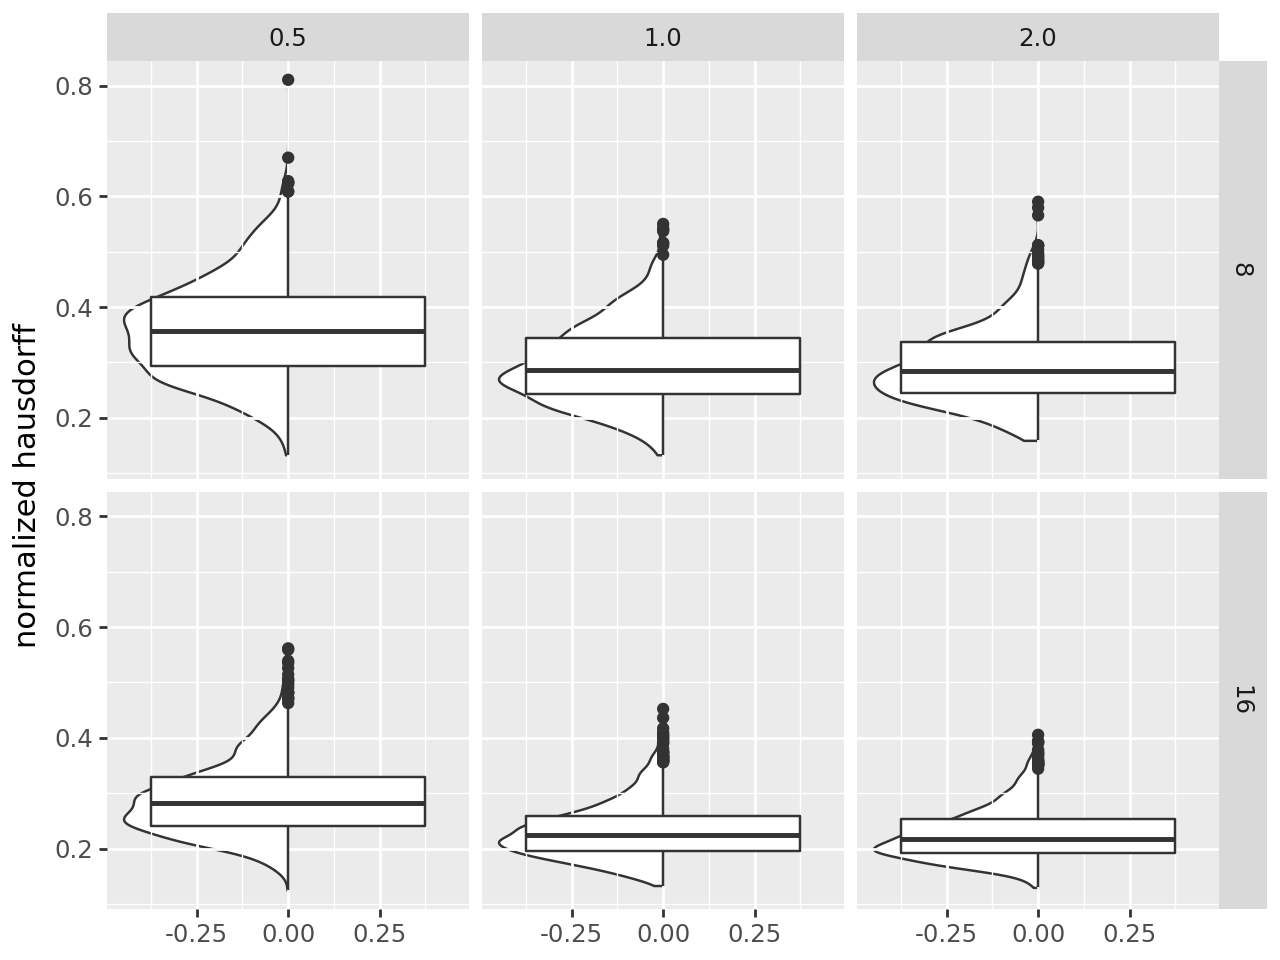

In [24]:
(p9.ggplot( df, p9.aes(y='normalized hausdorff'))
+ p9.geom_violin(style='left')
+ p9.geom_boxplot()
+ p9.facet_grid('num_a', 'frac_b')
)

In [25]:
df.groupby(['frac_b', 'num_a']).describe()['normalized hausdorff']

count      mean       std       min       25%       50%  \
frac_b num_a                                                             
0.5    8      1000.0  0.361818  0.090727  0.133402  0.293913  0.357389   
       16     1000.0  0.291665  0.068866  0.124397  0.241569  0.282305   
1.0    8      1000.0  0.296475  0.072822  0.133380  0.243902  0.286907   
       16     1000.0  0.232406  0.051173  0.133338  0.195530  0.224485   
2.0    8      1000.0  0.294012  0.069113  0.159405  0.244446  0.284646   
       16     1000.0  0.225664  0.047724  0.129966  0.192474  0.216975   

                   75%       max  
frac_b num_a                      
0.5    8      0.418393  0.810384  
       16     0.329752  0.561508  
1.0    8      0.343456  0.550162  
       16     0.259160  0.452221  
2.0    8      0.337740  0.590241  
       16     0.252596  0.405405

# Attempt: Code up a simulation that enables evaluation of e.g. hausdorff _during_ the optimization